In [9]:
# 1. Import all the tools we need
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [10]:
# 2. Load the Dataset
# California Housing dataset
# described in class: predicting a continuous number (house price) from a
# handful of features like income, house age, and location.
data = fetch_california_housing(as_frame=True)

X = data.frame.drop(columns=["MedHouseVal"])
y = data.frame["MedHouseVal"]                  # The target: median house value ($100,000s)

display(X.head())

print("\nTarget (median house value, in $100,000s):")
display(y.head())


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25



Target (median house value, in $100,000s):


0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64

In [ ]:
# 3. Split the data into Training and Testing sets
# We use 80% of the data to teach the tree, and keep 20% hidden to test it later.
# As covered in class, Decision Trees need minimal data prep -- no scaling required.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training features:", X_train.shape)
print("Testing features :", X_test.shape)


Training features: (16512, 8)
Testing features : (4128, 8)


In [ ]:
# 4. Build and Train the Decision Tree Regressor
# We set max_depth=6 so the tree stops "overthinking" and memorizing the training
# data -- exactly the overfitting problem described in class -- while still being
# deep enough to learn a useful pattern.
tree_model = DecisionTreeRegressor(max_depth=6, random_state=42)
tree_model.fit(X_train, y_train)

print("Tree actual depth:", tree_model.get_depth())
print("Tree leaf count  :", tree_model.get_n_leaves())


Tree actual depth: 6
Tree leaf count  : 64


In [13]:
# 5. Make Predictions on the hidden test data
predictions = tree_model.predict(X_test)


In [14]:
# 6. Evaluate the Model
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error  : {rmse:.4f}")
print(f"R-squared (R^2)           : {r2:.4f}")


Mean Absolute Error (MAE) : 0.5008
Mean Squared Error (MSE)  : 0.4973
Root Mean Squared Error  : 0.7052
R-squared (R^2)           : 0.6205


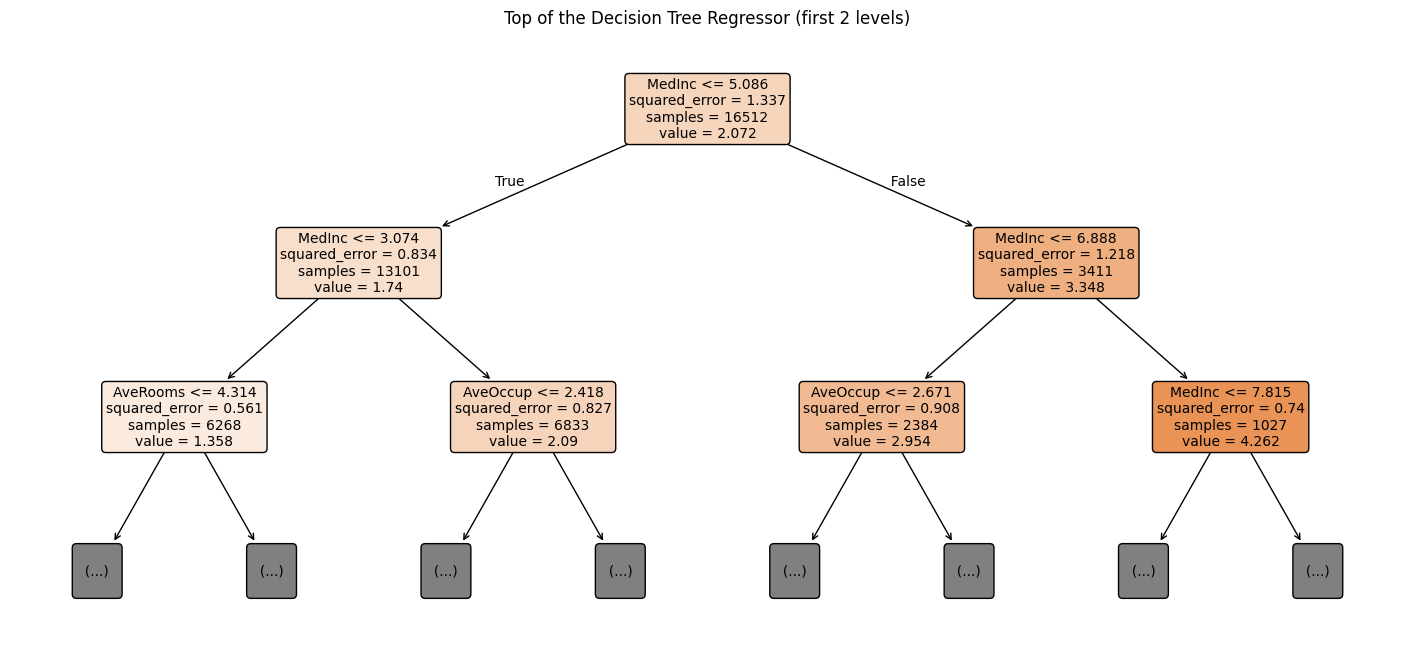

In [ ]:
# 7. Visualize the Top of the Tree
# The full tree is 6 levels deep, so we only render the first 2 levels here to
# keep it readable -- this is the "White-Box" interpretation idea from class:
# you can trace the path a house takes down these questions to see exactly why
# the model predicted the price it did.
plt.figure(figsize=(18, 8))
plot_tree(
    tree_model,
    max_depth=2,
    feature_names=X.columns,
    filled=True,      # Colors the boxes based on the predicted value
    rounded=True,     # Rounds the corners of the boxes
    fontsize=10
)
plt.title("Top of the Decision Tree Regressor (first 2 levels)")
plt.show()


Top 5 Most Important Features:
MedInc      0.729888
AveOccup    0.137787
HouseAge    0.043518
AveRooms    0.034038
Latitude    0.030302
dtype: float64


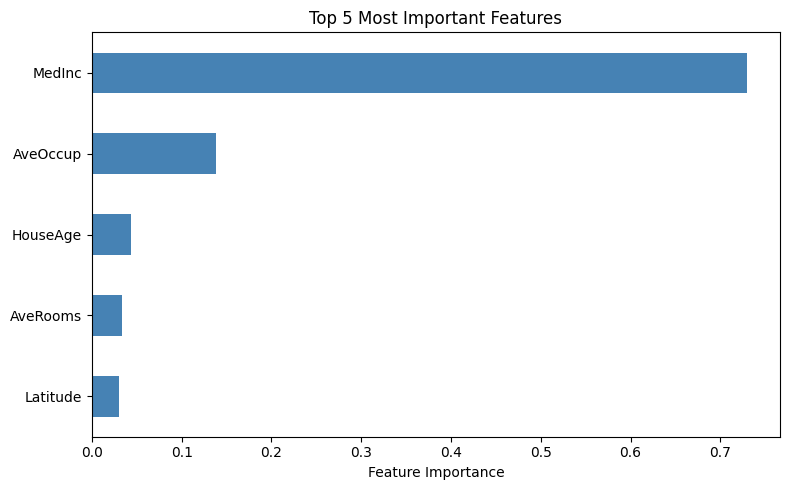

In [ ]:
# 8. Feature Importance -- Identify the Top 5 Most Important Features
# feature_importances_ tells us how much each feature helped reduce error (MSE)
feature_importance = pd.Series(
    tree_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_5_features = feature_importance.head(5)

print("Top 5 Most Important Features:")
print(top_5_features)

plt.figure(figsize=(8, 5))
top_5_features.sort_values().plot(kind="barh", color="steelblue")
plt.title("Top 5 Most Important Features")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()


## Feature Importance Interpretation

The tree's `feature_importances_` scores show how much each feature reduced
prediction error (MSE) every time the tree used it to split the data -- the
same idea covered in class. The top 5 features were:

1. **MedInc (median income, ~73% importance)** -- by far the most important
   feature. This makes intuitive sense: neighborhoods with higher median
   income can support higher house prices, so this is the question the tree
   asks first (the Root Node) to make its biggest initial split.
2. **AveOccup (average household occupancy, ~14% importance)** -- how many
   people live in an average household in that block group. Very high
   occupancy often signals overcrowded, lower-value housing, while unusually
   low occupancy can signal vacation homes or high-end housing with few
   occupants -- both push prices away from the "typical" range.
3. **HouseAge (median house age, ~4% importance)** -- older housing stock
   can mean lower value due to wear, or higher value in historic /
   established neighborhoods, so it refines the price estimate after income
   and occupancy have done most of the work.
4. **AveRooms (average rooms per household, ~3% importance)** -- a rough
   proxy for house size. More rooms generally means a larger, more valuable
   home, though it matters far less than income once the tree has already
   split on it.
5. **Latitude (~3% importance)** -- location within California. Since this
   dataset is built from real census block groups, latitude captures some of
   the north/south price differences (e.g. proximity to expensive coastal
   areas), even without an explicit "distance to the coast" feature.

Together these 5 features account for the vast majority of the tree's
importance scores, while `Longitude`, `Population`, and `AveBedrms` contributed
very little -- meaning they were rarely used, or only made tiny improvements,
when the tree searched for the best question to ask at each split.